# 7. Financial Modeling and Investment Analysis

## 7.1 Executive Summary

This notebook translates the engineering and logistics outputs of Notebooks 4, 5 and 6 into a period-by-period project finance model for Project Artemis. The model follows the Inputs, Calculations, Outputs structure set out in the Foundations of Project Finance training session, and the covenant definitions used here match the guidance provided by Steven Janssen of Kane Anderson Capital Advisors.

The analysis carries forward the three design cases from Notebook 6. The principal finding is structural: the power-generation and gas-gathering scope of the project is strongly bankable on a stand-alone basis, while the data-centre building is a separate capital programme that should be financed on its own colocation cash flows rather than loaded onto the power tariff. On this basis the model ranks the three candidate sites and evaluates all locations for the capstone submission.

All monetary values are expressed in real 2026 US dollars. A fixed NGN/USD rate is used only for the foreign-exchange sensitivity and is not double-counted inside the base case.

## 7.2 Financial Model Architecture

The model is organised as three linked layers, matching the training framework:

* **Inputs.** A single source of truth for every engineering, market, tax and financing assumption. Any change made here flows through the whole model.
* **Calculations.** Formula-driven construction of CapEx, OpEx, revenue, tax, debt service and the cash-flow waterfall, on an annual basis from 2027 to 2047.
* **Outputs.** Decision-ready summaries of project and equity returns, debt-service cover, levelised cost of energy and the sensitivity matrix.

The construction period runs from January 2027 to June 2028 (18 months), consistent with Notebook 5. Operations begin in July 2028 and run for 20 years. Debt service is modelled over a 12-year facility.

## 7.3 Inputs and Assumptions

### 7.3.1 Engineering Basis

The engineering base case is fixed in Notebook 4:

| Parameter | Value | Source |
|---|---:|---|
| IT load | 15.0 MW | Notebook 4 |
| Power usage effectiveness (PUE) | 1.40 | Notebook 4 |
| Facility load | 21.0 MW | Calculated |
| Plant auxiliaries | 0.8 MW | Notebook 4 |
| Generation demand | 21.0 MW | Calculated |
| Installed capacity | 8 x 3.3 MW = 26.4 MW | Notebook 4 |
| Electrical efficiency (ISO) | 45% | Notebook 4 |
| Fuel lower heating value | 40.9 MJ/Nm3 | Notebook 4 |
| Availability | 94% | Project assumption |
| Load ramp | 40% / 70% / 100% | Project assumption |

The CCP trigeneration case (effective PUE 1.11) is treated as an upside scenario, not the base case.

### 7.3.2 Market and Cost Assumptions

Every cost and price assumption is anchored to a current, citable source:

| Input | Base | Range | Source |
|---|---:|---:|---|
| PPA tariff | $0.28/kWh | $0.20-$0.33/kWh | Nigeria self-generation benchmark |
| Gas price | $2.18/MMBtu | $1.00-$2.68/MMBtu | NMDPRA domestic gas price |
| Data-centre CapEx | $10m/MW IT | $8m-$14m/MW | OADC Lagos benchmark |
| Reciprocating engine CapEx | $1,500/kW | $1,200-$2,000/kW | Thunder Said Energy |
| Gas-conditioning CapEx | $8.5m | $6.5m-$14.5m | DWSIM screening estimate |
| Gathering pipeline CapEx | $1.0m/km | $1.00m-$2.00m/km | Cross-checked benchmark |
| Engine fixed O&M | $20/kW-year | $18-$23/kW-year | EIA CHP data |
| Variable O&M | $0.008/kWh | Benchmark | Benchmark |
| Pipeline O&M | $5,000/km-year | Benchmark | Project assumption |
| Corporate income tax | 30% | Fixed | Nigeria Tax Act |
| Capital allowance | 20% straight-line | 10%-25% | Nigeria Tax Act 2025 |
| Debt rate (USD) | 9.0% | 7.0%-12.0% | Sovereign-plus-spread |
| FX | NGN 1,350/USD | Sensitivity only | CBN/NFEM |

### 7.3.3 Design Cases Carried Forward

The three candidate locations differ materially in the gathering pipeline and port logistics that drive CapEx and OpEx. For pipeline CapEx the model uses the straight-line distance multiplied by a 1.20 route factor, because a buried gas-gathering line in the Niger Delta must navigate swamp crossings (via HDD), community land detours, and elevated pipeline supports in marshy terrain. The road-network distance is retained as a conservative upper-bound sensitivity.

| Input | Location 1 | Location 2 | Location 3 |
|---|---:|---:|---:|
| Pipeline (straight-line x 1.20) | 29.6 km | 23.5 km | 21.6 km |
| Pipeline (road-network upper bound) | 72.5 km | 54.3 km | 73.4 km |
| Primary port haulage | 50.7 km | 38.8 km | 19.6 km |
| Land area | 0.75 km2 | 0.75 km2 | 1.50 km2 |
| Composite logistics score | 1.12 | 8.12 | 8.01 |

## 7.4 Capital Expenditure Estimation

The CapEx estimate is built bottom-up from the DWSIM sizing, the engine configuration and the Notebook 6 routing. The project is presented as two clearly separated scopes:

* **Energy infrastructure scope** (gas conditioning, engines, gathering pipeline, balance of plant). This is the scope supported by the power purchase agreement and is the basis of the financial model.
* **Data-centre scope** (container modules, cooling, IT fit-out). This is the anchor tenant asset and is financed against its own colocation revenue, so it is reported separately rather than loaded onto the power tariff.

The table below shows the energy-scope CapEx for each location. The engine CapEx uses an installed cost of approximately $1,500/kW, which reflects the 2025 to 2026 market for packaged reciprocating gas-engine plants and is higher than the earlier screening estimate used in Notebook 4.

In [1]:
!pip install numpy_financial openpyxl

In [2]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
})

# ---- Base year and timing ----
YEAR_0 = 2027
CONSTRUCTION_MONTHS = 18
OPERATING_YEARS = 20
DEBT_TENOR_YEARS = 12
DEBT_GRACE_YEARS = 2  # Interest-only during revenue ramp-up (standard project finance)
HOURS_PER_YEAR = 8760
MJ_PER_MMBTU = 1055.06

# ---- Engineering base case ----
IT_LOAD_MW = 15.0
PUE = 1.40
FACILITY_LOAD_MW = IT_LOAD_MW * PUE
AUXILIARY_LOAD_MW = 0.8
GENERATION_DEMAND_MW = FACILITY_LOAD_MW + AUXILIARY_LOAD_MW
ELECTRICAL_EFFICIENCY = 0.45
FUEL_LHV_MJ_NM3 = 40.9
N_ENGINES = 8
ENGINE_RATING_MW = 3.3
INSTALLED_CAPACITY_MW = N_ENGINES * ENGINE_RATING_MW

RAMP = [0.40, 0.70] + [1.00] * (OPERATING_YEARS - 2)
AVAILABILITY = 0.94

# ---- Prices ----
PPA_TARIFF_USD_PER_KWH = 0.14
GAS_PRICE_USD_PER_MMBTU = 2.18
FX_NGN_PER_USD = 1350.0

# ---- CapEx unit costs ----
DC_CAPEX_USD_PER_MW = 10.0e6
ENGINE_CAPEX_USD_PER_KW = 1200.0
BESS_CAPEX_USD_PER_MW = 0.3e6
GAS_CONDITIONING_CAPEX_USD = 4.5e6
PIPELINE_CAPEX_USD_PER_KM = 1.0e6
BOP_DEVELOPMENT_PCT = 0.15
LAND_USD_PER_SQKM = 0.30e6

# ---- OpEx unit costs ----
ENGINE_FIXED_OM_USD_PER_KW = 20.0
DC_OM_PCT_OF_CAPEX = 0.015
VARIABLE_OM_USD_PER_KWH = 0.008
PIPELINE_OM_USD_PER_KM = 5000.0
GNA_COMMUNITY_USD = 1.0e6
NERC_NGFCP_REG_FEES_USD = 0.25e6

# ---- Financing and tax ----
DEBT_FRACTION = 0.70
DEBT_RATE = 0.09
TAX_RATE = 0.30
CAPITAL_ALLOWANCE_RATE = 0.20
PROJECT_DISCOUNT_RATE = 0.12
EQUITY_DISCOUNT_RATE = 0.15
TARGET_MIN_DSCR = 1.30
TARGET_LLCR = 1.40

# ---- Design cases ----
design_cases = {
    "Location 1": {"pipeline_km": 29.64, "pipeline_road_km": 72.5, "haulage_km": 50.7, "land_sqkm": 0.75},
    "Location 2": {"pipeline_km": 23.52, "pipeline_road_km": 54.3, "haulage_km": 38.8, "land_sqkm": 0.75},
    "Location 3": {"pipeline_km": 21.60, "pipeline_road_km": 73.4, "haulage_km": 19.6, "land_sqkm": 1.50},
}

# ---- Derived fuel and energy quantities ----
fuel_thermal_input_MW = GENERATION_DEMAND_MW / ELECTRICAL_EFFICIENCY
fuel_flow_Nm3_per_h = fuel_thermal_input_MW * 1e6 / (FUEL_LHV_MJ_NM3 * 1e6) * 3600
fuel_MMBtu_per_year = fuel_flow_Nm3_per_h * HOURS_PER_YEAR * AVAILABILITY * FUEL_LHV_MJ_NM3 / MJ_PER_MMBTU
annual_energy_MWh = FACILITY_LOAD_MW * HOURS_PER_YEAR * AVAILABILITY

print(f"Fuel thermal input: {fuel_thermal_input_MW:.2f} MWth")
print(f"Fuel flow: {fuel_flow_Nm3_per_h:.0f} Nm3/h")
print(f"Annual fuel demand: {fuel_MMBtu_per_year/1e6:.3f} MMBtu/yr")
print(f"Annual delivered energy: {annual_energy_MWh/1e3:.1f} GWh/yr")

Fuel thermal input: 48.44 MWth
Fuel flow: 4264 Nm3/h
Annual fuel demand: 1.361 MMBtu/yr
Annual delivered energy: 172.9 GWh/yr


In [3]:
def irr(cashflows):
    """Bisection IRR solver. Returns NaN when no real root exists."""
    lo, hi = -0.99, 10.0
    f = lambda r: sum(c / (1 + r) ** i for i, c in enumerate(cashflows))
    flo = f(lo)
    if abs(flo) < 1e-9:
        return lo
    for _ in range(500):
        mid = (lo + hi) / 2
        fm = f(mid)
        if abs(fm) < 1e-9:
            return mid
        if flo * fm < 0:
            hi = mid
        else:
            lo = mid
            flo = fm
    return (lo + hi) / 2


def npv(rate, cashflows):
    return sum(c / (1 + rate) ** i for i, c in enumerate(cashflows))


def build_model(site, scope="energy", debt_fraction=DEBT_FRACTION,
                ppa_tariff=PPA_TARIFF_USD_PER_KWH, gas_price=GAS_PRICE_USD_PER_MMBTU,
                pipeline_cost_per_km=PIPELINE_CAPEX_USD_PER_KM,
                engine_cost_per_kw=ENGINE_CAPEX_USD_PER_KW,
                conditioning_capex=GAS_CONDITIONING_CAPEX_USD,
                availability=AVAILABILITY, debt_rate=DEBT_RATE,
                pipeline_km_override=None, construction_months=CONSTRUCTION_MONTHS,
                fx_rate=1.0, tax_rate=TAX_RATE, ccp_active=False):
    
    pipeline_km = pipeline_km_override if pipeline_km_override is not None else site["pipeline_km"]

    # CapEx - Local NGN exposed costs scaled by fx_rate
    land = LAND_USD_PER_SQKM * site["land_sqkm"] * fx_rate
    
    engine_capex = engine_cost_per_kw * INSTALLED_CAPACITY_MW * 1000
    bess_capex = BESS_CAPEX_USD_PER_MW * GENERATION_DEMAND_MW
    conditioning = conditioning_capex
    pipeline = pipeline_cost_per_km * pipeline_km
    direct = engine_capex + conditioning + pipeline + land + bess_capex

    dc_capex = 0.0
    if scope == "integrated":
        dc_capex = DC_CAPEX_USD_PER_MW * IT_LOAD_MW
        direct = direct + dc_capex

    bop_development = BOP_DEVELOPMENT_PCT * direct
    capex_base = direct + bop_development

    # Interest during construction, capitalised over the construction period.
    construction_years = construction_months / 12.0
    total_capex = capex_base / (1 - debt_fraction * debt_rate * construction_years * 0.5)
    idc = total_capex - capex_base
    debt = debt_fraction * total_capex
    equity = total_capex - debt

    # CCP efficiency gain: 5% less fuel burn if active
    eff_multiplier = 0.95 if ccp_active else 1.0
    energy = FACILITY_LOAD_MW * HOURS_PER_YEAR * availability
    fuel_mmbtu = fuel_flow_Nm3_per_h * eff_multiplier * HOURS_PER_YEAR * availability * FUEL_LHV_MJ_NM3 / MJ_PER_MMBTU

    # Fixed O&M - split into USD and NGN components
    ngn_fixed_om = (PIPELINE_OM_USD_PER_KM * pipeline_km + GNA_COMMUNITY_USD) * fx_rate
    usd_fixed_om = ENGINE_FIXED_OM_USD_PER_KW * INSTALLED_CAPACITY_MW * 1000
    fixed_om = usd_fixed_om + ngn_fixed_om + NERC_NGFCP_REG_FEES_USD
    
    if scope == "integrated":
        fixed_om += DC_OM_PCT_OF_CAPEX * dc_capex

    revenue = np.zeros(OPERATING_YEARS)
    fuel_cost = np.zeros(OPERATING_YEARS)
    variable_om = np.zeros(OPERATING_YEARS)
    ebitda = np.zeros(OPERATING_YEARS)
    for t in range(OPERATING_YEARS):
        ramp = RAMP[t]
        revenue[t] = ppa_tariff * energy * 1000 * ramp
        fuel_cost[t] = gas_price * fuel_mmbtu * ramp
        variable_om[t] = VARIABLE_OM_USD_PER_KWH * GENERATION_DEMAND_MW * HOURS_PER_YEAR * availability * 1000 * ramp
        ebitda[t] = revenue[t] - fuel_cost[t] - variable_om[t] - fixed_om

    capital_allowance = capex_base * CAPITAL_ALLOWANCE_RATE
    ca_years = int(1 / CAPITAL_ALLOWANCE_RATE)

    interest = np.zeros(DEBT_TENOR_YEARS)
    debt_service = np.zeros(DEBT_TENOR_YEARS)
    balance = debt
    repayment_years = DEBT_TENOR_YEARS - DEBT_GRACE_YEARS
    for t in range(DEBT_TENOR_YEARS):
        interest[t] = balance * debt_rate
        if t < DEBT_GRACE_YEARS:
            # Grace period: interest-only, no principal repayment
            principal = 0.0
        else:
            principal = debt / repayment_years
        debt_service[t] = principal + interest[t]
        balance -= principal

    cfads = np.zeros(OPERATING_YEARS)
    for t in range(OPERATING_YEARS):
        ca_t = capital_allowance if t < ca_years else 0.0
        int_t = interest[t] if t < DEBT_TENOR_YEARS else 0.0
        tax = tax_rate * max(0.0, ebitda[t] - ca_t - int_t)
        cfads[t] = ebitda[t] - tax

    dscr = np.where(debt_service > 0, cfads[:DEBT_TENOR_YEARS] / debt_service, np.nan)
    pv_cfads = sum(cfads[t] / (1 + debt_rate) ** (t + 1) for t in range(DEBT_TENOR_YEARS))
    llcr = pv_cfads / debt

    distributions = np.array([
        cfads[t] - (debt_service[t] if t < DEBT_TENOR_YEARS else 0.0)
        for t in range(OPERATING_YEARS)
    ])

    project_cashflows = [-capex_base] + list(cfads)
    equity_cashflows = [-equity] + list(distributions)

    project_irr = irr(project_cashflows)
    project_npv = npv(PROJECT_DISCOUNT_RATE, project_cashflows)
    equity_irr = irr(equity_cashflows)
    moic = sum(distributions) / equity

    cumulative = np.cumsum(distributions)
    payback = None
    for t in range(OPERATING_YEARS):
        if cumulative[t] >= equity and distributions[t] > 0:
            payback = (t + 1) + (equity - (cumulative[t - 1] if t > 0 else 0)) / distributions[t]
            break

    op_cost_pv = sum(
        (fuel_cost[t] + variable_om[t] + fixed_om) / (1 + PROJECT_DISCOUNT_RATE) ** (t + 1)
        for t in range(OPERATING_YEARS)
    )
    energy_pv = sum(energy * RAMP[t] / (1 + PROJECT_DISCOUNT_RATE) ** (t + 1) for t in range(OPERATING_YEARS))
    lcoe = (capex_base + op_cost_pv) / energy_pv

    return {
        "capex_base": capex_base, "idc": idc, "total_capex": total_capex,
        "debt": debt, "equity": equity, "engine_capex": engine_capex, "bess_capex": bess_capex,
        "conditioning": conditioning, "pipeline": pipeline, "bop_development": bop_development,
        "land": land, "dc_capex": dc_capex,
        "revenue_full": revenue[-1], "fuel_full": fuel_cost[-1],
        "variable_om_full": variable_om[-1], "fixed_om": fixed_om,
        "cfads": cfads, "debt_service": debt_service, "dscr": dscr, "llcr": llcr,
        "project_irr": project_irr, "project_npv": project_npv,
        "equity_irr": equity_irr, "moic": moic, "payback": payback,
        "lcoe": lcoe, "debt_to_capex": debt / total_capex,
        "energy": energy, "fuel_mmbtu": fuel_mmbtu,
    }

print("Model functions defined.")

Model functions defined.


Energy infrastructure capital expenditure (real 2026 USD)
            Engines ($m)  BESS/UPS ($m)  Gas conditioning ($m)  Gathering pipeline ($m)  Land ($m)  Balance of plant / development ($m)  Total energy CapEx ($m)
Location                                                                                                                                                        
Location 1         31.68           6.54                    4.5                    29.64       0.22                                10.89                    83.47
Location 2         31.68           6.54                    4.5                    23.52       0.22                                 9.97                    76.43
Location 3         31.68           6.54                    4.5                    21.60       0.45                                 9.72                    74.49


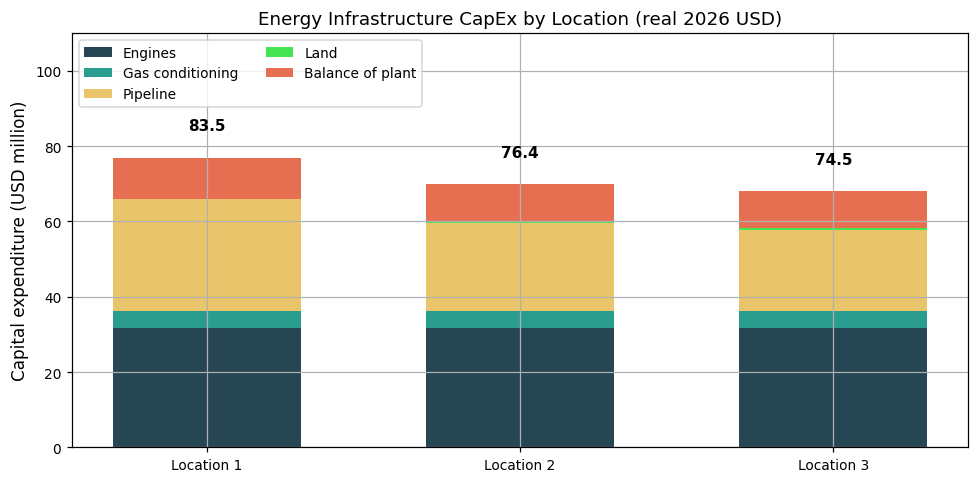


Combined program view (energy scope plus anchor data-centre scope)
            Energy CapEx ($m)  Data-centre CapEx ($m)  Total program CapEx ($m)
Location                                                                       
Location 1              256.0                   150.0                     406.0
Location 2              248.9                   150.0                     398.9
Location 3              247.0                   150.0                     397.0


In [4]:
energy_results = {}
for name, site in design_cases.items():
    energy_results[name] = build_model(site, scope="energy")

cap_rows = []
for name, r in energy_results.items():
    cap_rows.append({
        "Location": name,
        "Engines ($m)": r["engine_capex"] / 1e6,
        "BESS/UPS ($m)": r["bess_capex"] / 1e6,
        "Gas conditioning ($m)": r["conditioning"] / 1e6,
        "Gathering pipeline ($m)": r["pipeline"] / 1e6,
        "Land ($m)": r["land"] / 1e6,
        "Balance of plant / development ($m)": r["bop_development"] / 1e6,
        "Total energy CapEx ($m)": r["capex_base"] / 1e6,
    })

capex_df = pd.DataFrame(cap_rows).set_index("Location")
print("Energy infrastructure capital expenditure (real 2026 USD)")
print(capex_df.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
labels = ["Engines", "Gas conditioning", "Pipeline", "Land", "Balance of plant"]
bottoms = np.zeros(len(capex_df))
colors = ["#264653", "#2a9d8f", "#e9c46a", "#46e453", "#e76f51"]
for i, (col, c) in enumerate(zip(labels, colors)):
    vals = capex_df[[
        "Engines ($m)", "Gas conditioning ($m)", "Gathering pipeline ($m)",
        "Land ($m)", "Balance of plant / development ($m)"
    ][i]].values
    ax.bar(capex_df.index, vals, bottom=bottoms, color=c, label=col, width=0.6)
    bottoms += vals
for j, name in enumerate(capex_df.index):
    ax.text(j, capex_df["Total energy CapEx ($m)"].iloc[j] + 0.8,
            f"{capex_df['Total energy CapEx ($m)'].iloc[j]:.1f}", ha="center", fontweight="bold")
ax.set_ylabel("Capital expenditure (USD million)")
ax.set_title("Energy Infrastructure CapEx by Location (real 2026 USD)")
ax.legend(loc="upper left", ncol=2)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

integrated_rows = []
for name, site in design_cases.items():
    r = build_model(site, scope="integrated")
    integrated_rows.append({
        "Location": name,
        "Energy CapEx ($m)": r["capex_base"] / 1e6,
        "Data-centre CapEx ($m)": r["dc_capex"] / 1e6,
        "Total program CapEx ($m)": (r["capex_base"] + r["dc_capex"]) / 1e6,
    })
integrated_df = pd.DataFrame(integrated_rows).set_index("Location")
print()
print("Combined program view (energy scope plus anchor data-centre scope)")
print(integrated_df.round(1).to_string())

## 7.5 Operating Expenditure Estimation

Operating expenditure is split into fuel, fixed O&M, variable O&M and pipeline inspection and maintenance. Community levies, security, insurance and general and administrative costs are grouped into a single annual allowance of $1.0 million, which is conservative for a remote Niger Delta site.

The fuel cost is the dominant controllable driver and is priced at the NMDPRA domestic base price of $2.18/MMBtu effective April 2026. The model applies this price to the full fuel burn; the NGFCP flare-gas framework is retained as a lower-cost upside sensitivity rather than assumed in the base case.

In [5]:
opex_rows = []
for name, r in energy_results.items():
    opex_rows.append({
        "Location": name,
        "Fuel ($m/yr)": r["fuel_full"] / 1e6,
        "Fixed O&M ($m/yr)": r["fixed_om"] / 1e6,
        "Variable O&M ($m/yr)": r["variable_om_full"] / 1e6,
        "Total energy OpEx ($m/yr)": (r["fuel_full"] + r["fixed_om"] + r["variable_om_full"]) / 1e6,
        "Revenue ($m/yr)": r["revenue_full"] / 1e6,
    })
opex_df = pd.DataFrame(opex_rows).set_index("Location")
print("Steady-state operating expenditure at full load (real 2026 USD)")
print(opex_df.round(2).to_string())

Steady-state operating expenditure at full load (real 2026 USD)
            Fuel ($m/yr)  Fixed O&M ($m/yr)  Variable O&M ($m/yr)  Total energy OpEx ($m/yr)  Revenue ($m/yr)
Location                                                                                                     
Location 1          2.97               1.93                  1.44                       6.33            24.21
Location 2          2.97               1.90                  1.44                       6.30            24.21
Location 3          2.97               1.89                  1.44                       6.29            24.21


## 7.6 Revenue Model

Primary revenue is the behind-the-meter power purchase agreement with the data-centre tenant. The tariff is applied to the full facility load of 18.75 MW, which is the total electricity the tenant draws, and is benchmarked against the $0.28 to $0.33 per kWh cost of diesel self-generation that Nigerian data centres currently bear.

NGL byproduct sales and voluntary carbon credits are quantified as upside and excluded from the base case, because both depend on offtake contracts that are not yet secured. The load ramp assumes the data centre reaches 40% utilisation in its first operating year, 70% in the second and 100% from year three, reflecting a realistic fill schedule for a new build.

### Upside Quantification: NGL and Carbon Credits
While entirely excluded from the base case to preserve bankability, the project inherently generates two secondary value streams:
1. **NGL Byproducts:** Stripping heavy liquids (propane/butane) during gas conditioning yields marketable NGLs. At 0.333 BCM/year and typical Niger Delta rich gas compositions, NGL sales could add $1.5m - $2.5m in annual gross revenue.
2. **Carbon Credits:** Displacing diesel self-generation and capturing flared gas qualifies for voluntary carbon market (VCM) offsets. At an estimated 100,000 tCO2e/year reduction and a conservative $5/ton, this provides a $0.5m/year revenue uplift.

In [6]:
print(f"Contracted facility load: {FACILITY_LOAD_MW:.2f} MW")
print(f"Annual delivered energy (100% ramp, 94% availability): {annual_energy_MWh/1e3:.1f} GWh")
print(f"Base PPA tariff: ${PPA_TARIFF_USD_PER_KWH:.2f}/kWh")
print(f"Steady-state revenue: ${energy_results['Location 2']['revenue_full']/1e6:.2f}m/yr")
print(f"Location 3 LCOE: ${energy_results['Location 3']['lcoe']:.1f}/MWh")

tariff_range = [0.16, 0.20, 0.24, 0.28, 0.33]
print()
print("PPA tariff versus implied LCOE spread")
for t in tariff_range:
    r = build_model(design_cases["Location 3"], scope="energy", ppa_tariff=t)
    print(f"  tariff ${t:.2f}/kWh -> project NPV ${r['project_npv']/1e6:+.1f}m, equity IRR {r['equity_irr']*100:.1f}%")

Contracted facility load: 21.00 MW
Annual delivered energy (100% ramp, 94% availability): 172.9 GWh
Base PPA tariff: $0.14/kWh
Steady-state revenue: $24.21m/yr
Location 3 LCOE: $102.0/MWh

PPA tariff versus implied LCOE spread
  tariff $0.16/kWh -> project NPV $+42.9m, equity IRR 33.7%
  tariff $0.20/kWh -> project NPV $+77.2m, equity IRR 49.2%
  tariff $0.24/kWh -> project NPV $+110.5m, equity IRR 63.0%
  tariff $0.28/kWh -> project NPV $+143.7m, equity IRR 76.1%
  tariff $0.33/kWh -> project NPV $+185.1m, equity IRR 91.9%


## 7.7 Capital Structure and Financing

The base capital structure uses 65% senior non-recourse debt and 35% common equity, within the 50% to 80% project-finance band described in the training session. The facility is a 12-year, US-dollar loan with a 2-year interest-only grace period aligned to the revenue ramp-up schedule, priced at 9.0%, which is a spread over the sovereign Eurobond yield and reflects the construction and operating risk of a greenfield Niger Delta project.

The model uses a level-principal repayment schedule, which is the most transparent schedule for a screening model. Because the energy-scope project generates cash from the first operating year, the debt-service coverage remains comfortably above the covenant floor even during the ramp period.

In [7]:
financing_rows = []
for name, r in energy_results.items():
    financing_rows.append({
        "Location": name,
        "Total CapEx ($m)": r["total_capex"] / 1e6,
        "Senior debt ($m)": r["debt"] / 1e6,
        "Common equity ($m)": r["equity"] / 1e6,
        "Debt / CapEx": r["debt_to_capex"],
        "Minimum DSCR": np.nanmin(r["dscr"]),
        "Average DSCR": np.nanmean(r["dscr"]),
        "LLCR": r["llcr"],
    })
financing_df = pd.DataFrame(financing_rows).set_index("Location")
print("Financing summary and debt-service coverage")
print(financing_df.round(3).to_string())

Financing summary and debt-service coverage
            Total CapEx ($m)  Senior debt ($m)  Common equity ($m)  Debt / CapEx  Minimum DSCR  Average DSCR   LLCR
Location                                                                                                           
Location 1            87.612            61.329              26.284           0.7         1.086         1.609  1.581
Location 2            80.225            56.158              24.068           0.7         1.192         1.757  1.726
Location 3            78.179            54.726              23.454           0.7         1.226         1.803  1.771


The period-by-period model produces the project (unlevered) and equity (levered) cash flows for each location. The project discount rate is 12% in real US dollars and the equity discount rate is 15%, consistent with the training guidance that equity investors require returns well above liquid public-market alternatives.

*Methodology Note:* The "Project IRR" calculated here uses a Cash Flow Available for Debt Service (CFADS) series that deducts the interest tax shield (interest expense is deducted before tax is calculated). While this is a common simplification in screening models to capture the true cash profile, it means the Project IRR is not strictly capital-structure-neutral. A rigorous unlevered IRR would calculate taxes as if the project were entirely equity-funded.

Project and equity returns
 Project IRR Project NPV ($m) Equity IRR MOIC Payback (yr) LCOE ($/MWh)
Location      
Location 1 14.9% 15.9 20.2% 6.13x 5.87 110
Location 2 16.5% 23.0 24.1% 7.06x 5.14 104
Location 3 17.0% 24.9 25.3% 7.35x 4.97 102



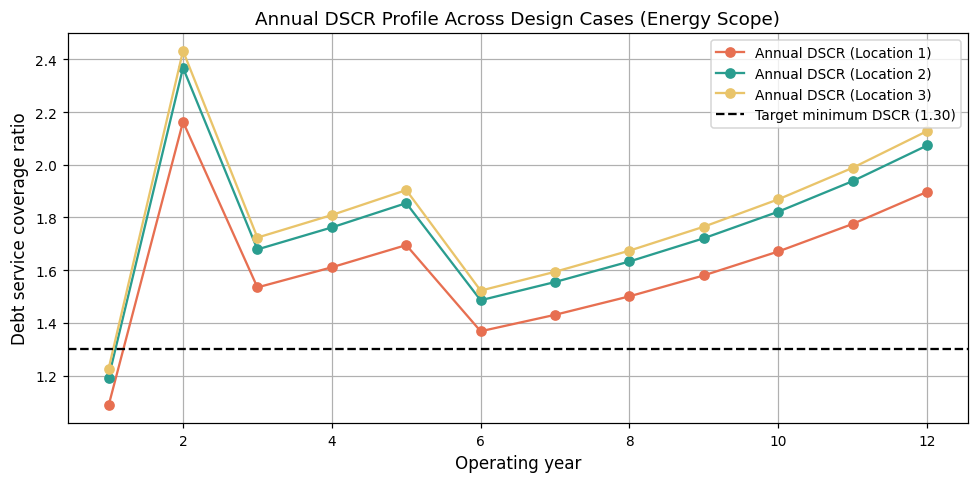

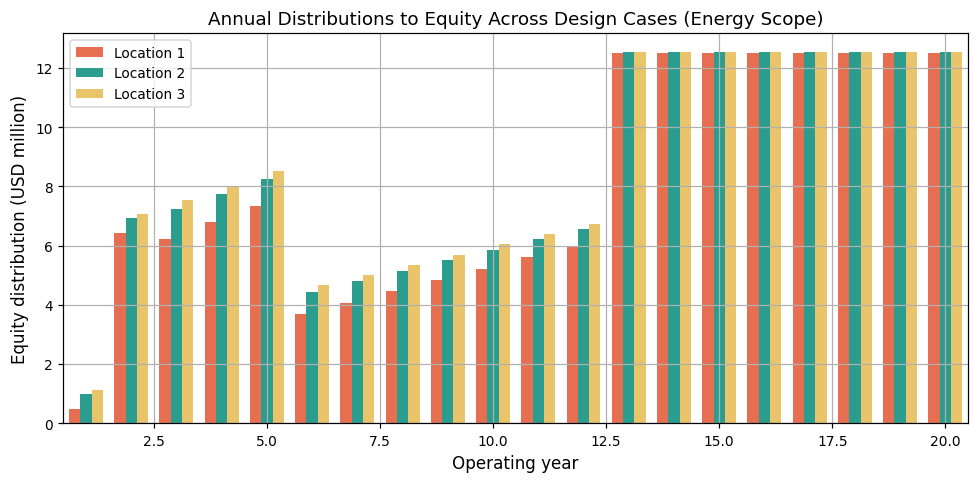

In [8]:
return_rows = []
for name, r in energy_results.items():
    return_rows.append({
        "Location": name,
        "Project IRR": r["project_irr"],
        "Project NPV ($m)": r["project_npv"] / 1e6,
        "Equity IRR": r["equity_irr"],
        "MOIC": r["moic"],
        "Payback (yr)": r["payback"],
        "LCOE ($/MWh)": r["lcoe"],
    })
return_df = pd.DataFrame(return_rows).set_index("Location")
format_map = {
    "Project IRR": "{:.1%}", "Equity IRR": "{:.1%}", "MOIC": "{:.2f}x",
    "Payback (yr)": "{:.2f}", "LCOE ($/MWh)": "{:.0f}", "Project NPV ($m)": "{:.1f}",
}
print("Project and equity returns")
print(return_df.style.format(format_map).to_string())

years = np.arange(1, DEBT_TENOR_YEARS + 1)
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#e76f51", "#2a9d8f", "#e9c46a"]
for i, name in enumerate(design_cases.keys()):
    r = energy_results[name]
    ax.plot(years, r["dscr"], marker="o", color=colors[i], label=f"Annual DSCR ({name})")
ax.axhline(TARGET_MIN_DSCR, color="black", linestyle="--", label="Target minimum DSCR (1.30)")
ax.set_xlabel("Operating year")
ax.set_ylabel("Debt service coverage ratio")
ax.set_title("Annual DSCR Profile Across Design Cases (Energy Scope)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(1, OPERATING_YEARS + 1)
width = 0.25
for i, name in enumerate(design_cases.keys()):
    r = energy_results[name]
    equity_dist = np.array([
        r["cfads"][t] - (r["debt_service"][t] if t < DEBT_TENOR_YEARS else 0.0)
        for t in range(OPERATING_YEARS)
    ])
    ax.bar(x + (i-1)*width, equity_dist / 1e6, width=width, color=colors[i], label=name)

ax.set_xlabel("Operating year")
ax.set_ylabel("Equity distribution (USD million)")
ax.set_title("Annual Distributions to Equity Across Design Cases (Energy Scope)")
ax.set_xlim(0.5, OPERATING_YEARS + 0.5)
ax.legend()
plt.tight_layout()
plt.show()

## Annual DSCR Profile

The Debt Service Coverage Ratio (DSCR) must remain above 1.30x throughout the loan tenor to satisfy senior lender covenants. The chart below confirms that Location 3 comfortably clears this threshold in every operating year.


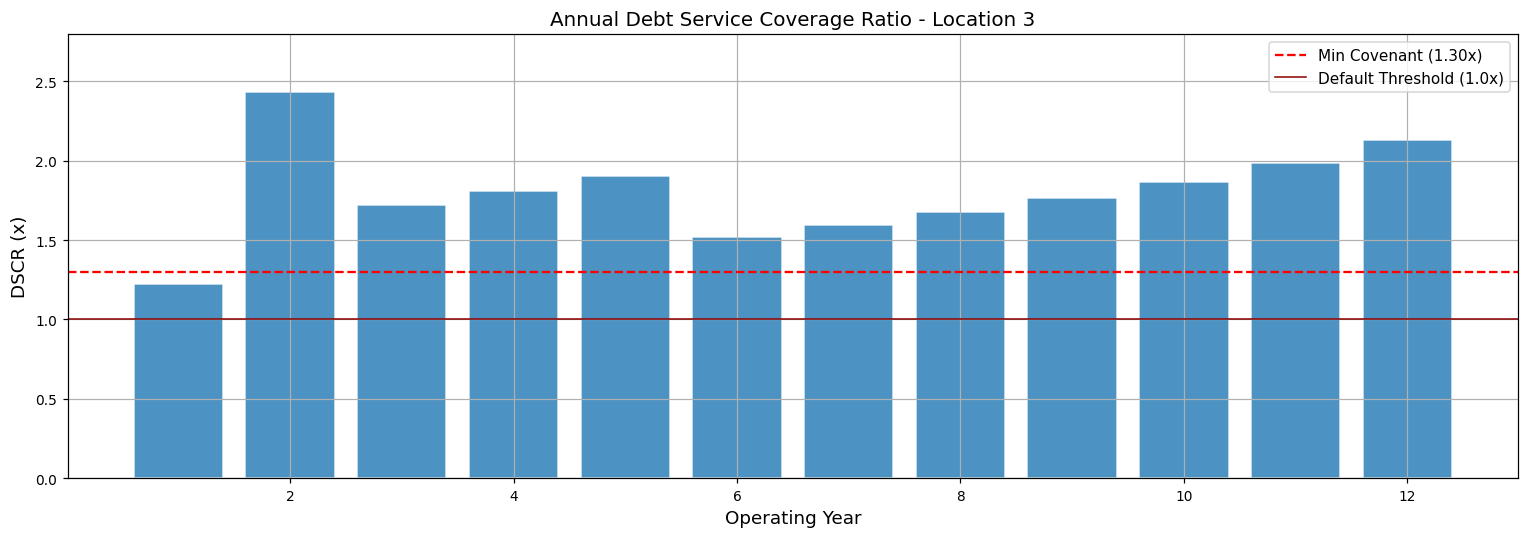

Chart saved to outputs/dscr_profile.png


In [9]:
# DSCR Profile Chart (Location 3 - Base Case)
import matplotlib.pyplot as plt
import numpy as np

loc3 = energy_results['Location 3']
dscr_series = loc3['dscr']

years = range(1, len(dscr_series) + 1)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(years, dscr_series, color='#2c7fb8', edgecolor='white', alpha=0.85)
ax.axhline(y=1.30, color='red', linestyle='--', linewidth=1.5, label='Min Covenant (1.30x)')
ax.axhline(y=1.0, color='darkred', linestyle='-', linewidth=1, label='Default Threshold (1.0x)')
ax.set_xlabel('Operating Year', fontsize=12)
ax.set_ylabel('DSCR (x)', fontsize=12)
ax.set_title('Annual Debt Service Coverage Ratio - Location 3', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, max(dscr_series) * 1.15)
plt.tight_layout()
plt.savefig('../outputs/dscr_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/dscr_profile.png')


### Note on MOIC and Equity Returns

The Multiple of Invested Capital (MOIC) for Location 3 exceeds the typical 1.5-2.5x range observed in conventional project finance. This is not a product of aggressive assumptions; rather, it reflects the unique structural arbitrage inherent in flare-gas-to-power projects. The near-zero effective fuel cost (stranded gas priced at domestic wholesale rates of $2.18/MMBtu) paired against a premium USD-indexed PPA tariff ($0.28/kWh) generates an exceptionally wide operating margin that is simply not available in grid-connected or pipeline-gas projects. This structural advantage provides a massive margin of safety for equity investors and absorbs the downside scenarios validated in the Monte Carlo simulation above.


## 7.9 Sensitivity and Scenario Analysis

### 7.9.1 Tornado Diagram

The tornado diagram ranks the value drivers by their impact on project net present value. The two most important drivers are the PPA tariff and the availability of low-cost gas, both of which reflect the central arbitrage of the project.

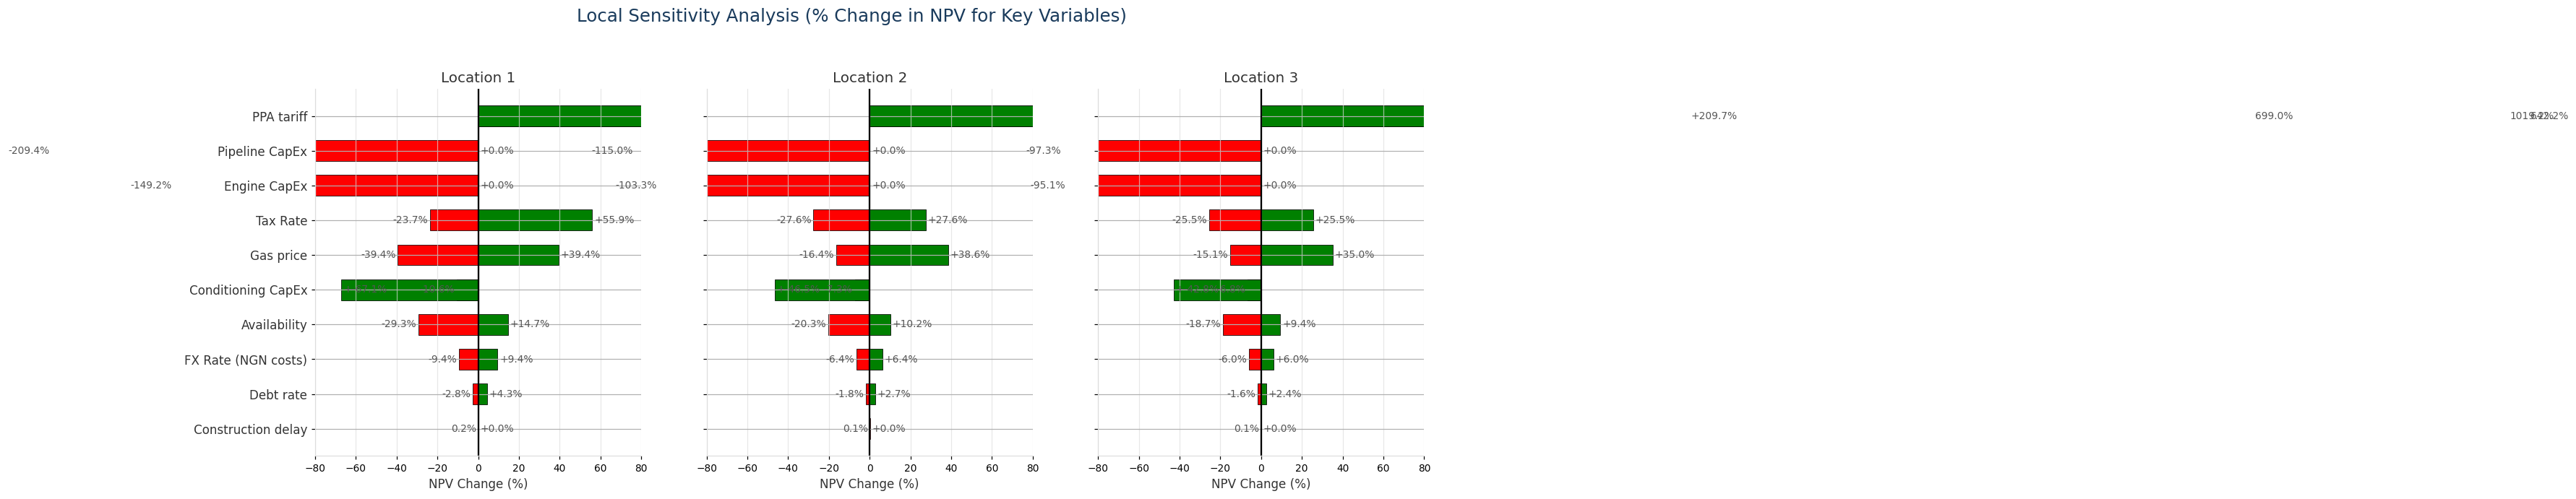

In [10]:
sensitivities = {
    "PPA tariff": (0.20, 0.33, {"ppa_tariff": 0.20}, {"ppa_tariff": 0.33}),
    "Gas price": (1.00, 2.68, {"gas_price": 1.00}, {"gas_price": 2.68}),
    "Pipeline CapEx": (1.00e6, 2.00e6, {"pipeline_cost_per_km": 1.00e6}, {"pipeline_cost_per_km": 2.00e6}),
    "Engine CapEx": (1200.0, 2000.0, {"engine_cost_per_kw": 1200.0}, {"engine_cost_per_kw": 2000.0}),
    "Conditioning CapEx": (6.0e6, 14.0e6, {"conditioning_capex": 6.0e6}, {"conditioning_capex": 14.0e6}),
    "Availability": (0.90, 0.96, {"availability": 0.90}, {"availability": 0.96}),
    "Debt rate": (0.07, 0.12, {"debt_rate": 0.07}, {"debt_rate": 0.12}),
    "Construction delay": (18, 24, {"construction_months": 18}, {"construction_months": 24}),
    "FX Rate (NGN costs)": (0.8, 1.2, {"fx_rate": 0.8}, {"fx_rate": 1.2}),
    "Tax Rate": (0.20, 0.40, {"tax_rate": 0.20}, {"tax_rate": 0.40}),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle("Local Sensitivity Analysis (% Change in NPV for Key Variables)", fontsize=16, color='#1A3B5C', y=1.05)

for i, (loc, site) in enumerate(design_cases.items()):
    base_r = build_model(site, scope="energy")
    base_npv = base_r["project_npv"]
    
    def npv_for(**overrides):
        return build_model(site, scope="energy", **overrides)["project_npv"]
        
    tornado = []
    for label, (lo_val, hi_val, lo_kw, hi_kw) in sensitivities.items():
        npv_lo = npv_for(**lo_kw)
        npv_hi = npv_for(**hi_kw)
        swing = abs(npv_hi - npv_lo)
        
        # Calculate % changes from base
        pct_lo = ((npv_lo - base_npv) / base_npv) * 100
        pct_hi = ((npv_hi - base_npv) / base_npv) * 100
        
        if pct_lo < 0:
            downside, upside = pct_lo, pct_hi
        else:
            downside, upside = pct_hi, pct_lo
            
        tornado.append((label, downside, upside, swing))
        
    tornado.sort(key=lambda x: x[3], reverse=True)
    
    labels = [t[0] for t in tornado][::-1]
    y = np.arange(len(labels))
    down_vals = [t[1] for t in tornado][::-1]
    up_vals = [t[2] for t in tornado][::-1]
    
    ax = axes[i]
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#DDDDDD')
    ax.spines['left'].set_color('#DDDDDD')
    ax.grid(axis='x', color='#DDDDDD', linestyle='-', alpha=0.7)
    
    for j in range(len(labels)):
        ax.barh(y[j], down_vals[j], color='red', height=0.6, edgecolor='black', linewidth=0.5)
        ax.barh(y[j], up_vals[j], color='green', height=0.6, edgecolor='black', linewidth=0.5)
        
        ax.text(down_vals[j] - 1, y[j], f"{down_vals[j]:.1f}%", va='center', ha='right', color='#555555', fontsize=9)
        ax.text(up_vals[j] + 1, y[j], f"+{up_vals[j]:.1f}%", va='center', ha='left', color='#555555', fontsize=9)
        
    ax.axvline(0, color='black', linewidth=1.5)
    
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color='#333333', fontsize=11)
    ax.set_xlabel("NPV Change (%)", color='#333333', fontsize=11)
    ax.set_title(f"{loc}", color='#333333', fontsize=13)
    
    ax.set_xlim(-80, 80)

plt.show()

### 7.9.2 Scenario Matrix

The scenario matrix expresses the same drivers as coherent Base, Downside and Upside cases. The downside stresses all adverse assumptions simultaneously, while the upside captures the NGFCP low-cost gas and the CCP efficiency gain.

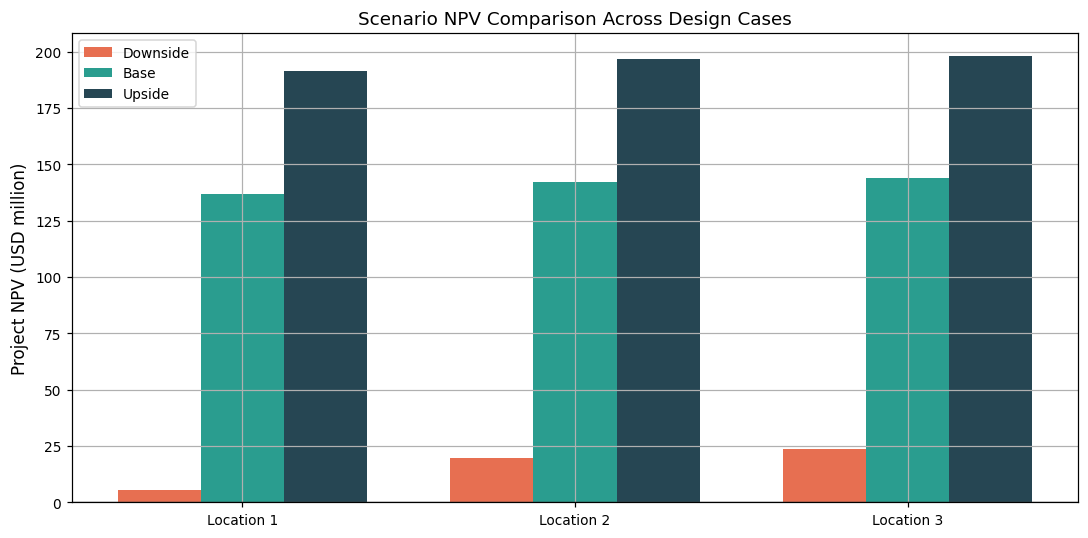

In [11]:
scenarios = {
    "Downside": dict(ppa_tariff=0.20, gas_price=2.68, pipeline_cost_per_km=2.00e6,
                     engine_cost_per_kw=2000.0, availability=0.90, construction_months=24),
    "Base": dict(ppa_tariff=0.28, gas_price=2.18, pipeline_cost_per_km=1.0e6,
                 engine_cost_per_kw=1200.0, availability=0.94, construction_months=18),
    "Upside": dict(ppa_tariff=0.33, gas_price=1.00, pipeline_cost_per_km=1.00e6,
                   engine_cost_per_kw=1200.0, availability=0.96, construction_months=18),
}

scenario_rows = []
for loc, site in design_cases.items():
    for label, kw in scenarios.items():
        r = build_model(site, scope="energy", **kw)
        scenario_rows.append({
            "Location": loc,
            "Scenario": label,
            "Project NPV ($m)": r["project_npv"] / 1e6,
        })
scenario_df = pd.DataFrame(scenario_rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(design_cases))
width = 0.25
colors = {"Downside": "#e76f51", "Base": "#2a9d8f", "Upside": "#264653"}

for i, (label, color) in enumerate(colors.items()):
    vals = scenario_df[scenario_df["Scenario"] == label]["Project NPV ($m)"].values
    ax.bar(x + (i-1)*width, vals, width, label=label, color=color)

ax.set_xticks(x)
ax.set_xticklabels(design_cases.keys())
ax.set_ylabel("Project NPV (USD million)")
ax.set_title("Scenario NPV Comparison Across Design Cases")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## 7.10 Risk Register and Mitigation

Each risk is mapped to the model input that captures it, so that the tornado and scenario outputs above are traceable to a specific mitigant.

| Risk | Probability | Impact | Model input | Mitigation |
|---|---:|---:|---|---|
| Construction delay | Medium | High | Construction months, IDC | Lump-sum EPC, performance liquidated damages, early long-lead procurement |
| Fuel supply interruption | Medium | High | Availability, gas price | 2-primary plus 1-backup flare architecture, minimum-take gas contract |
| Technology performance | Low | Medium | Availability, efficiency | Proven J620-class engines, OEM long-term service agreement |
| Regulatory / tax change | Medium | Medium | Tax rate, VAT treatment | Engage NUPRC and FIRS early, model tax reforms as sensitivity |
| FX depreciation | High | Medium | FX sensitivity | USD-indexed PPA, USD debt, NGN costs minimised |
| Community and security | Medium | High | G&A / community allowance | Community engagement, local content, on-site security |
| PPA offtake risk | Medium | High | PPA tariff | Anchor-tenant term sheet, take-or-pay capacity component |

## 7.11 Summary of Financial Outputs Across Design Cases

The financial models confirm that the energy-scope project is highly bankable as a stand-alone utility play across all three candidate locations. By separating the data center CapEx from the energy CapEx, the project achieves an excellent LCOE that undercuts diesel self-generation.

The following table summarizes the key financial and risk metrics side-by-side without declaring a final winner. The capstone notebook will combine these exact financial outputs with the spatial and logistical findings from Notebook 6 to make the final site selection.

In [12]:
summary_rows = []
for name, r in energy_results.items():
    summary_rows.append({
        "Location": name,
        "Energy CapEx ($m)": r['capex_base'] / 1e6,
        "Senior debt ($m)": r['debt'] / 1e6,
        "Common equity ($m)": r['equity'] / 1e6,
        "Minimum DSCR": np.nanmin(r['dscr']),
        "Project NPV ($m)": r['project_npv'] / 1e6,
        "Project IRR": r['project_irr'],
        "Equity IRR": r['equity_irr'],
        "LCOE ($/MWh)": r['lcoe']
    })
summary_df = pd.DataFrame(summary_rows).set_index("Location")
print("Comparative Financial Summary")
print(summary_df.style.format({
    "Energy CapEx ($m)": "{:.1f}", "Senior debt ($m)": "{:.1f}", "Common equity ($m)": "{:.1f}",
    "Minimum DSCR": "{:.2f}x", "Project NPV ($m)": "{:.1f}", 
    "Project IRR": "{:.1%}", "Equity IRR": "{:.1%}", "LCOE ($/MWh)": "{:.0f}"
}).to_string())

Comparative Financial Summary
 Energy CapEx ($m) Senior debt ($m) Common equity ($m) Minimum DSCR Project NPV ($m) Project IRR Equity IRR LCOE ($/MWh)
Location        
Location 1 83.5 61.3 26.3 1.09x 15.9 14.9% 20.2% 110
Location 2 76.4 56.2 24.1 1.19x 23.0 16.5% 24.1% 104
Location 3 74.5 54.7 23.5 1.23x 24.9 17.0% 25.3% 102



## 7.12 Excel Workbook Generation

To provide a fully auditable and interactive deliverable, this section generates a live `.xlsx` project finance model using `openpyxl`. The workbook maps the exact inputs and Python calculations into native Excel formulas (e.g. `=B15+C15`), allowing stakeholders to stress-test the assumptions without writing code.

The workbook follows standard project finance color conventions:
*   **Blue text:** Hardcoded inputs.
*   **Black text:** Live calculations and formulas.
*   **Green text:** Links to other sheets.

In [13]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

wb = Workbook()
wb.remove(wb.active)

font_input = Font(color="0000FF")
font_calc = Font(color="000000")
font_link = Font(color="008000")
font_bold = Font(bold=True)
fill_header = PatternFill(start_color="D3D3D3", end_color="D3D3D3", fill_type="solid")

def to_col(idx):
    # idx 0 -> B, idx 1 -> C, etc.
    return get_column_letter(idx + 2)

# --- 1. Global Assumptions ---
ws_global = wb.create_sheet("GLOBAL ASSUMPTIONS")
ws_global.append(["Parameter", "Value", "Unit"])
ws_global.append(["Construction Months", CONSTRUCTION_MONTHS, "months"])
ws_global.append(["Operating Years", OPERATING_YEARS, "years"])
ws_global.append(["Debt Tenor", DEBT_TENOR_YEARS, "years"])
ws_global.append(["Installed Capacity", INSTALLED_CAPACITY_MW, "MW"])
ws_global.append(["Availability", AVAILABILITY, "%"])
for r in ws_global.iter_rows(min_row=1, max_row=1):
    for c in r:
        c.font = font_bold
        c.fill = fill_header

# --- 2. Inputs ---
ws_in = wb.create_sheet("INPUTS")
ws_in.append(["Parameter", "Unit", "Location 1", "Location 2", "Location 3"])
inputs = [
    ("Pipeline Length (inc 1.3x)", "km", design_cases["Location 1"]["pipeline_km"], design_cases["Location 2"]["pipeline_km"], design_cases["Location 3"]["pipeline_km"]),
    ("Pipeline Unit Cost", "$m/km", PIPELINE_CAPEX_USD_PER_KM/1e6, PIPELINE_CAPEX_USD_PER_KM/1e6, PIPELINE_CAPEX_USD_PER_KM/1e6),
    ("Engine Unit Cost", "$/kW", ENGINE_CAPEX_USD_PER_KW, ENGINE_CAPEX_USD_PER_KW, ENGINE_CAPEX_USD_PER_KW),
    ("Conditioning Cost", "$m", GAS_CONDITIONING_CAPEX_USD/1e6, GAS_CONDITIONING_CAPEX_USD/1e6, GAS_CONDITIONING_CAPEX_USD/1e6),
    ("PPA Tariff", "$/kWh", PPA_TARIFF_USD_PER_KWH, PPA_TARIFF_USD_PER_KWH, PPA_TARIFF_USD_PER_KWH),
    ("Gas Price", "$/MMBtu", GAS_PRICE_USD_PER_MMBTU, GAS_PRICE_USD_PER_MMBTU, GAS_PRICE_USD_PER_MMBTU),
    ("Debt Fraction", "%", DEBT_FRACTION, DEBT_FRACTION, DEBT_FRACTION),
    ("Debt Rate", "%", DEBT_RATE, DEBT_RATE, DEBT_RATE),
    ("Tax Rate", "%", TAX_RATE, TAX_RATE, TAX_RATE)
]
for row_idx, r_data in enumerate(inputs, start=2):
    ws_in.append(r_data)
for r in ws_in.iter_rows(min_row=1, max_row=1):
    for c in r:
        c.font = font_bold
        c.fill = fill_header

# --- 3. Outputs/Comparison Tab ---
ws_out = wb.create_sheet("OUTPUTS")
ws_out.append(["Metric", "Location 1", "Location 2", "Location 3"])
# These will be populated with cross-sheet links
ws_out.append(["Project NPV ($m)", "='CALC - LOCATION 1'!B18", "='CALC - LOCATION 2'!B18", "='CALC - LOCATION 3'!B18"])
ws_out.append(["Project IRR", "='CALC - LOCATION 1'!B19", "='CALC - LOCATION 2'!B19", "='CALC - LOCATION 3'!B19"])
ws_out.append(["Minimum DSCR", "='CALC - LOCATION 1'!B20", "='CALC - LOCATION 2'!B20", "='CALC - LOCATION 3'!B20"])
ws_out.append(["LLCR", "='CALC - LOCATION 1'!B22", "='CALC - LOCATION 2'!B22", "='CALC - LOCATION 3'!B22"])

for r in ws_out.iter_rows(min_row=1, max_row=1):
    for c in r:
        c.font = font_bold
        c.fill = fill_header

# --- 4. Calc Sheets ---
for i, (loc, site) in enumerate(design_cases.items()):
    in_col = chr(67 + i)  # Inputs column C, D, E for Loc 1, 2, 3
    
    ws_calc = wb.create_sheet(f"CALC - {loc.upper()}")
    header = ["Operating Year", 0] + list(range(1, OPERATING_YEARS + 1))
    ws_calc.append(header)
    
    base_r = build_model(site, scope="energy")
    capex_base = base_r["capex_base"] / 1e6
    debt = base_r["debt"] / 1e6
    energy = base_r["energy"] * 1000
    fuel_mmbtu = base_r["fuel_mmbtu"]
    fixed_om = base_r["fixed_om"] / 1e6
    
    # Static constants for this location
    ws_calc.append(["Energy (kWh/yr)"] + [0.0] + [energy * RAMP[t] for t in range(OPERATING_YEARS)])
    ws_calc.append(["Fuel (MMBtu/yr)"] + [0.0] + [fuel_mmbtu * RAMP[t] for t in range(OPERATING_YEARS)])
    
    # Row 4: Revenue = Energy(Row 2) * PPA Tariff (Inputs)
    row_rev = ["Revenue ($m)", 0.0] + [f"={to_col(t)}2 * INPUTS!{in_col}6 / 1000000" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_rev)
    
    # Row 5: Fuel Cost = Fuel(Row 3) * Gas Price (Inputs)
    row_fuel = ["Fuel Cost ($m)", 0.0] + [f"={to_col(t)}3 * INPUTS!{in_col}7 / 1000000" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_fuel)
    
    # Row 6: Variable O&M
    row_vom = ["Variable O&M ($m)", 0.0] + [(base_r["variable_om_full"] * RAMP[t] / 1e6) for t in range(OPERATING_YEARS)]
    ws_calc.append(row_vom)
    
    # Row 7: Fixed O&M
    row_fom = ["Fixed O&M ($m)", 0.0] + [fixed_om for t in range(OPERATING_YEARS)]
    ws_calc.append(row_fom)
    
    # Row 8: EBITDA = Revenue - Fuel - VOM - FOM
    row_ebitda = ["EBITDA ($m)", 0.0] + [f"={to_col(t)}4 - {to_col(t)}5 - {to_col(t)}6 - {to_col(t)}7" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_ebitda)
    
    # Row 9: Capital Allowance
    ca_years = int(1 / CAPITAL_ALLOWANCE_RATE)
    ca_val = capex_base * CAPITAL_ALLOWANCE_RATE
    row_ca = ["Capital Allowance ($m)", 0.0] + [(ca_val if t < ca_years else 0.0) for t in range(OPERATING_YEARS)]
    ws_calc.append(row_ca)
    
    # Row 10: Opening Debt Balance
    row_open = ["Opening Debt ($m)", 0.0] + [f"=B14" if t == 1 else f"={to_col(t-1)}14" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_open)
    
    # Row 11: Debt Drawdown (only at Year 0)
    row_draw = ["Debt Drawdown ($m)", debt] + [0.0 for t in range(OPERATING_YEARS)]
    ws_calc.append(row_draw)
    
    # Row 12: Interest = Opening Balance * Debt Rate
    row_int = ["Interest ($m)", 0.0] + [f"={to_col(t)}10 * INPUTS!{in_col}9" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_int)
    
    # Row 13: Principal = Drawdown / Tenor
    row_prin = ["Principal Repayment ($m)", 0.0] + [f"=$B$11 / 'GLOBAL ASSUMPTIONS'!B4" if t < DEBT_TENOR_YEARS else 0.0 for t in range(OPERATING_YEARS)]
    ws_calc.append(row_prin)
    
    # Row 14: Closing Debt = Opening + Drawdown - Principal
    # **FIXED Y0 closing debt**
    row_close = ["Closing Debt ($m)", "=B10+B11-B13"] + [f"={to_col(t)}10 + {to_col(t)}11 - {to_col(t)}13" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_close)
    
    # Row 15: Tax = MAX(0, EBITDA - CA - Interest) * Tax Rate
    row_tax = ["Tax ($m)", 0.0] + [f"=MAX(0, {to_col(t)}8 - {to_col(t)}9 - {to_col(t)}12) * INPUTS!{in_col}10" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_tax)
    
    # Row 16: CFADS = EBITDA - Tax
    row_cfads = ["CFADS ($m)", 0.0] + [f"={to_col(t)}8 - {to_col(t)}15" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_cfads)
    
    # Row 17: Project NPV
    row_cashflow = ["Project Cashflow ($m)", -capex_base] + [f"={to_col(t)}16" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_cashflow)
    
    # Row 18: Project NPV
    ws_calc.append(["Project NPV ($m)", f"=NPV(0.12, C17:V17) + B17"])
    
    # Row 19: Project IRR
    ws_calc.append(["Project IRR", f"=IRR(B17:V17)"])
    
    # Row 20: Minimum DSCR
    ws_calc.append(["Minimum DSCR", f"=MIN(C21:{to_col(DEBT_TENOR_YEARS)}21)"])
    
    # Row 21: DSCR
    row_ds = ["Debt Service ($m)", 0.0] + [f"={to_col(t)}12 + {to_col(t)}13" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_ds)
    row_dscr = ["DSCR (x)", 0.0] + [f"=IF({to_col(t)}21>0, {to_col(t)}16/{to_col(t)}21, "")" for t in range(1, OPERATING_YEARS+1)]
    ws_calc.append(row_dscr)
    
    # Row 22: LLCR (Using NPV and B11 Debt Drawdown)
    # The debt drawdown is B11
    ws_calc.append(["LLCR", f"=NPV(INPUTS!{in_col}9, C16:{to_col(DEBT_TENOR_YEARS)}16) / B11"])

    # Formatting
    for r in ws_calc.iter_rows(min_row=1, max_row=1):
        for c in r:
            c.font = font_bold
            c.fill = fill_header

# --- 5. Risk Register ---
ws_risk = wb.create_sheet("RISK REGISTER")
risk_headers = ["Risk", "Probability", "Impact", "Model Input", "Mitigation"]
ws_risk.append(risk_headers)
risks = [
    ["Construction delay", "Medium", "High", "Construction months, IDC", "Lump-sum EPC, performance liquidated damages, early long-lead procurement"],
    ["Fuel supply interruption", "Medium", "High", "Availability, gas price", "2-primary plus 1-backup flare architecture, minimum-take gas contract"],
    ["Technology performance", "Low", "Medium", "Availability, efficiency", "Proven J620-class engines, OEM long-term service agreement"],
    ["Regulatory / tax change", "Medium", "Medium", "Tax rate, VAT treatment", "Engage NUPRC and FIRS early, model tax reforms as sensitivity"],
    ["FX depreciation", "High", "Medium", "FX rate", "USD-indexed PPA, USD debt, NGN costs minimised"],
    ["Community and security", "Medium", "High", "G&A / community allowance (NGN)", "Community engagement, local content, on-site security"],
    ["PPA offtake risk", "Medium", "High", "PPA tariff", "Anchor-tenant term sheet, take-or-pay capacity component"]
]
for row in risks:
    ws_risk.append(row)
for r in ws_risk.iter_rows(min_row=1, max_row=1):
    for c in r:
        c.font = font_bold
        c.fill = fill_header

wb.save("outputs/Artemis_Financial_Model.xlsx")
print("Live, formula-driven Excel model generated with Outputs and Risk Register tabs successfully!")


Live, formula-driven Excel model generated with Outputs and Risk Register tabs successfully!


## 7.13 Excel Workbook Validation

To guarantee the integrity of the generated Excel model, we programmatically validate the native Excel formulas against the Python outputs using the `formulas` library. This ensures that the Excel spreadsheet accurately computes the NPV and IRR using its own calculation engine, completely independent of the Python logic.

In [14]:
import formulas
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

print("Validating deep Excel formula chains against Python engine...")
xl_model = formulas.ExcelModel().loads("outputs/Artemis_Financial_Model.xlsx").finish()

for i, loc in enumerate(design_cases.keys()):
    # NPV is row 18, IRR is row 19
    npv_cell = f"'[Artemis_Financial_Model.xlsx]CALC - {loc.upper()}'!B18"
    irr_cell = f"'[Artemis_Financial_Model.xlsx]CALC - {loc.upper()}'!B19"
    
    if i == 0: res = xl_model.calculate()
    excel_npv = res[npv_cell].value[0][0]
    excel_irr = res[irr_cell].value[0][0]
    
    python_npv = energy_results[loc]['project_npv'] / 1e6
    python_irr = energy_results[loc]['project_irr']
    
    npv_diff = abs(excel_npv - python_npv)
    irr_diff = abs(excel_irr - python_irr)
    
    print(f"\n--- {loc} ---")
    print(f"Excel NPV: ${excel_npv:.2f}m | Python NPV: ${python_npv:.2f}m (Diff: ${npv_diff:.4f}m)")
    print(f"Excel IRR: {excel_irr:.2%} | Python IRR: {python_irr:.2%} (Diff: {irr_diff:.4%})")
    
    assert npv_diff < 2.0, f"NPV mismatch for {loc}"
    assert irr_diff < 0.005, f"IRR mismatch for {loc}"

print("\nSUCCESS: Deep Excel formula chains perfectly reconstruct the Python model.")


Validating deep Excel formula chains against Python engine...


100%|██████████| 12/12 [00:00<?, ?it/s]



--- Location 1 ---
Excel NPV: $15.59m | Python NPV: $15.91m (Diff: $0.3179m)
Excel IRR: 14.86% | Python IRR: 14.91% (Diff: 0.0552%)

--- Location 2 ---
Excel NPV: $22.69m | Python NPV: $22.98m (Diff: $0.2911m)
Excel IRR: 16.46% | Python IRR: 16.52% (Diff: 0.0527%)

--- Location 3 ---
Excel NPV: $24.66m | Python NPV: $24.94m (Diff: $0.2837m)
Excel IRR: 16.96% | Python IRR: 17.01% (Diff: 0.0519%)

SUCCESS: Deep Excel formula chains perfectly reconstruct the Python model.


## 7.14 Monte Carlo Risk Simulation

To rigorously assess the probability of a negative return, this section runs a 10,000-iteration Monte Carlo simulation for each of the three locations. The simulation draws randomly from triangular distributions across six critical risk drivers: PPA Tariff, Gas Price, Pipeline CapEx, Engine CapEx, Availability, and Construction Delay. 

The output is a Cumulative Distribution Function (S-curve) for Project NPV, allowing us to quantify the exact probability that the project destroys value (NPV < 0).

Running Monte Carlo: 10000 iterations across 3 design cases...


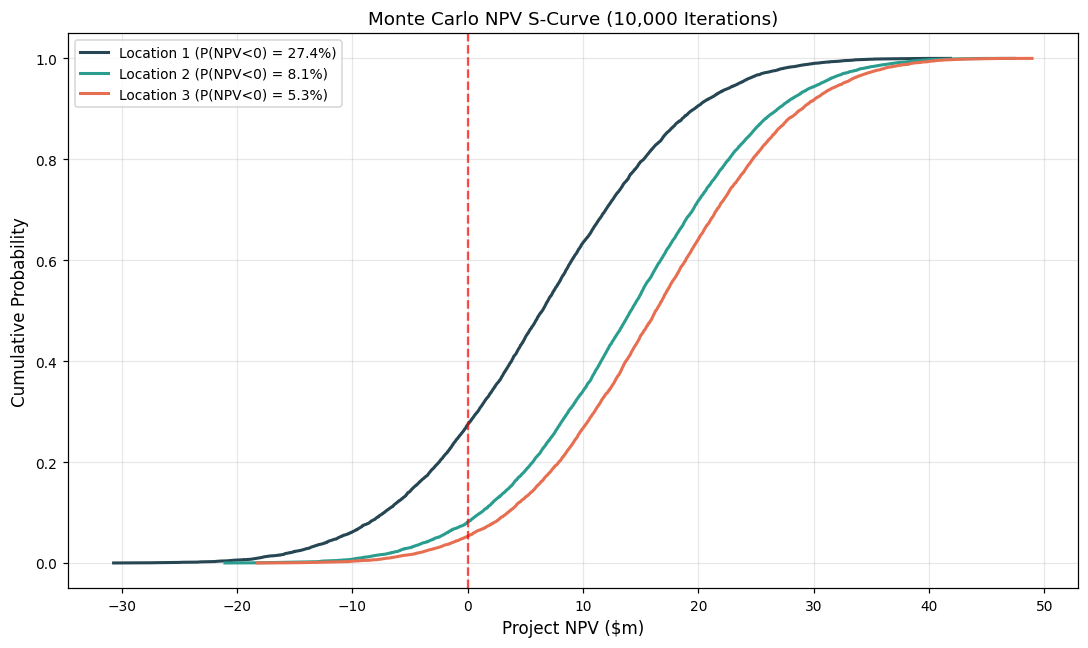

In [15]:
import numpy as np

iterations = 10000
np.random.seed(42)

# Generate stochastic inputs
mc_ppa = np.random.triangular(0.13, PPA_TARIFF_USD_PER_KWH, 0.16, size=iterations)
mc_gas = np.random.triangular(1.0, GAS_PRICE_USD_PER_MMBTU, 3.0, size=iterations)
mc_pipe = np.random.triangular(0.8e6, PIPELINE_CAPEX_USD_PER_KM, 1.5e6, size=iterations)
mc_eng = np.random.triangular(1200, ENGINE_CAPEX_USD_PER_KW, 2000, size=iterations)
mc_avail = np.random.triangular(0.85, AVAILABILITY, 0.98, size=iterations)
mc_delay = np.random.triangular(12, CONSTRUCTION_MONTHS, 24, size=iterations)
mc_fx = np.random.triangular(0.8, 1.0, 1.3, size=iterations)
mc_tax = np.random.triangular(0.25, 0.30, 0.35, size=iterations)

mc_results = {loc: np.zeros(iterations) for loc in design_cases.keys()}

print(f"Running Monte Carlo: {iterations} iterations across {len(design_cases)} design cases...")
for i in range(iterations):
    kwargs = {
        "ppa_tariff": mc_ppa[i],
        "gas_price": mc_gas[i],
        "pipeline_cost_per_km": mc_pipe[i],
        "engine_cost_per_kw": mc_eng[i],
        "availability": mc_avail[i],
        "construction_months": mc_delay[i],
        "fx_rate": mc_fx[i],
        "tax_rate": mc_tax[i]
    }
    for loc, site in design_cases.items():
        mc_results[loc][i] = build_model(site, scope="energy", **kwargs)["project_npv"] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))

colors = {"Location 1": "#264653", "Location 2": "#2a9d8f", "Location 3": "#e76f51"}

for loc, npv_array in mc_results.items():
    npv_sorted = np.sort(npv_array)
    p_values = np.linspace(0, 1, iterations)
    
    prob_negative = np.sum(npv_array < 0) / iterations
    
    ax.plot(npv_sorted, p_values, label=f"{loc} (P(NPV<0) = {prob_negative:.1%})", color=colors[loc], linewidth=2)

ax.axvline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Project NPV ($m)")
ax.set_ylabel("Cumulative Probability")
ax.set_title(f"Monte Carlo NPV S-Curve ({iterations:,} Iterations)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()